In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

from pylops import LinearOperator
from pylops.optimization.basic import lsqr

from pyproximal import TV
from pyproximal.optimization.primal import ADMML2

from diffavoinv.utils import *
from diffavoinv.vel_shaping_tools import *

### Data loading

In [6]:
nztrue= 1220 ; nxtrue= 984
vp = np.fromfile('../data/C_Otway2D/Velocity_model_2D/M_Sodas_Ln.vp', dtype=np.float32).reshape(nztrue,nxtrue).T ; print(vp.shape)
vs = np.fromfile('../data/C_Otway2D/Velocity_model_2D/M_Sodas_Ln.vs',  dtype=np.float32).reshape(nztrue,nxtrue).T
rho = np.fromfile('../data/C_Otway2D/Velocity_model_2D/M_Sodas_Ln.rho', dtype=np.float32).reshape(nztrue,nxtrue).T

mtrue = np.stack((vp,vs,rho), axis=0); print(mtrue.shape)

(984, 1220)
(3, 984, 1220)


In [7]:
# load: columns = [idx, c1, c2]
arr = np.loadtxt("/home/brandof/Documents/dpsAVOinversion-dev/data/C_Otway2D/Velocity_model_2D/SODAS_model_coords.txt")
c1 = arr[:,1]
c2 = arr[:,2]

ds = np.sqrt(np.diff(c1)**2 + np.diff(c2)**2)
print("mean ds:", ds.mean())
print("min ds :", ds.min())
print("max ds :", ds.max())

mean ds: 2.0000018495429783
min ds : 1.9991248085097142
max ds : 2.0106963967740943


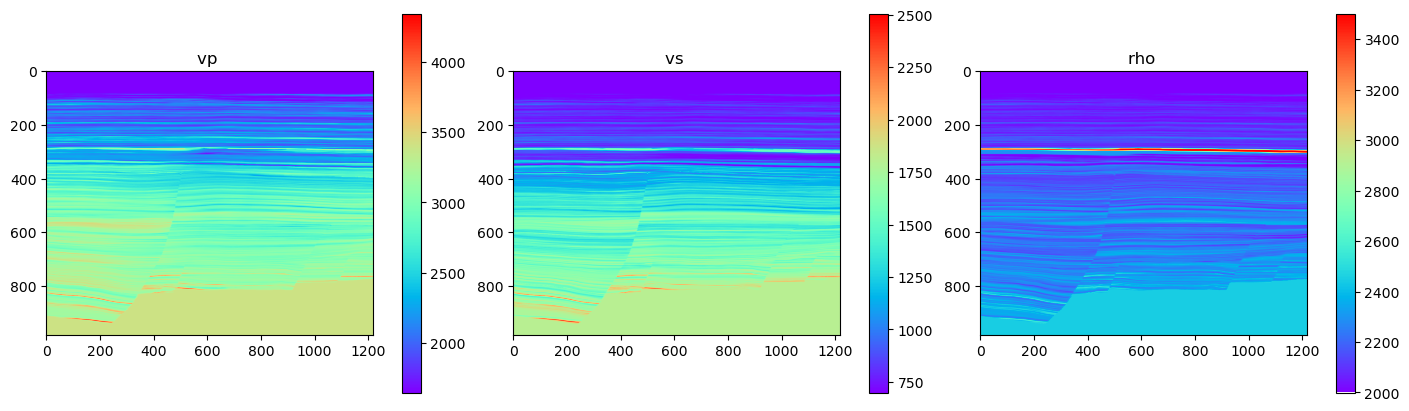

In [8]:
# Show stacked wells
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp, cmap='rainbow');  axs[0].set_title("vp ");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs, cmap='rainbow');  axs[1].set_title("vs ");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho, cmap='rainbow'); axs[2].set_title("rho "); plt.colorbar(im, ax=axs[2])
plt.show()

In [9]:
# # 2) Upsample height to 128 (keep width 256)
m_smooth = F.avg_pool2d(torch.from_numpy(mtrue), kernel_size=3, stride=1, padding=1)

m_up = F.interpolate(m_smooth.unsqueeze(0), size=( 128, 256), mode="area")
print(m_up.shape)

m_upsample = m_up.squeeze().numpy()

print(mtrue.shape, m_upsample.shape)

torch.Size([1, 3, 128, 256])
(3, 984, 1220) (3, 128, 256)


In [10]:
import numpy as np

# original sample positions (index along axis)
s_old = np.arange(1220)          # 0..1219
s_new = np.linspace(0, 1219, 256)

c1_new = np.interp(s_new, s_old, c1)
c2_new = np.interp(s_new, s_old, c2)


dz_old = 2.0
z_old = np.arange(984) * dz_old
z_new = np.linspace(z_old[0], z_old[-1], 128)

dz_new = z_new[1] - z_new[0]
print("dz_new:", dz_new)

# Resampled coordinates:
extent = [s_new[0], s_new[-1], z_new[-1], z_new[0]]

dz_new: 15.48031496062992


In [11]:
s_new[1]- s_new[0], z_new[1]- z_new[0]

(4.780392156862745, 15.48031496062992)

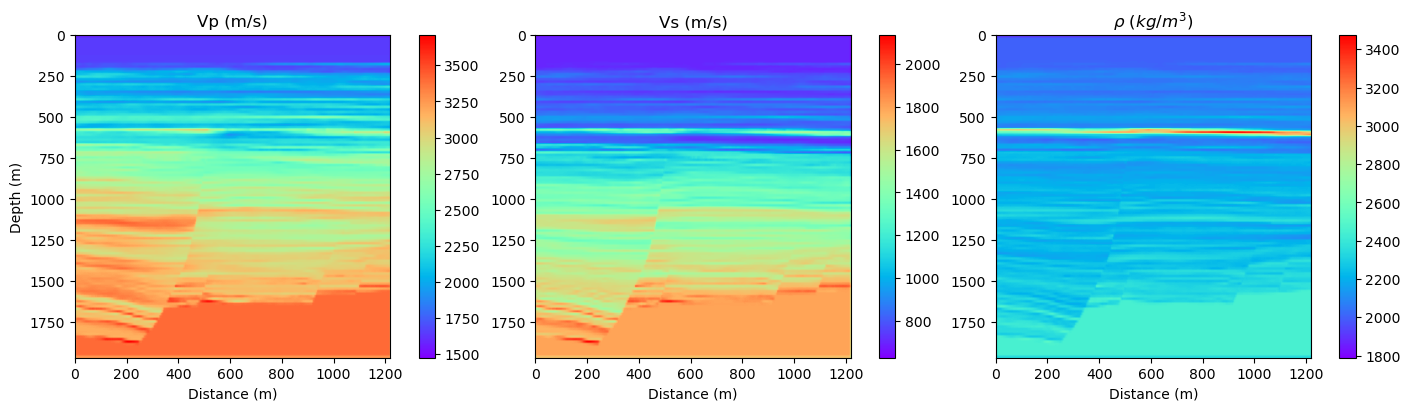

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

im = axs[0].imshow(m_upsample[0], cmap='rainbow', extent=extent, aspect='auto')
axs[0].set_title("Vp (m/s)")
axs[0].set_xlabel("Distance (m)")
axs[0].set_ylabel("Depth (m)")
plt.colorbar(im, ax=axs[0])

im = axs[1].imshow(m_upsample[1], cmap='rainbow', extent=extent, aspect='auto')
axs[1].set_title("Vs (m/s)")
axs[1].set_xlabel("Distance (m)")
plt.colorbar(im, ax=axs[1])

im = axs[2].imshow(m_upsample[2], cmap='rainbow', extent=extent, aspect='auto')
axs[2].set_title(r"$\rho$ $(kg/m^3)$")
axs[2].set_xlabel("Distance (m)")
plt.colorbar(im, ax=axs[2])


In [ ]:
# np.savez('/home/brandof/Documents/dpsAVOinversion-dev/data/C_Otway2D/otway_128_256.npz', m=m_upsample, x=s_new, z=z_new)

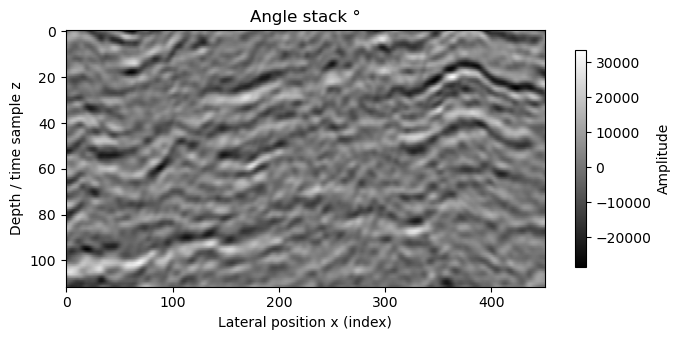

In [3]:
# Plot angle: x-location
ix_angle = 0                     # angle index to plot
# theta_val = theta[ix_angle]

fig, ax = plt.subplots(figsize=(7, 3.5))

im = ax.imshow(
    angle_stack_load[:, 2, :],
    cmap="gray",
    aspect="auto",
    origin="upper",
       # x index, z sample
)

ax.set_title(f"Angle stack °")
ax.set_xlabel("Lateral position x (index)")
ax.set_ylabel("Depth / time sample z")

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Amplitude")

plt.tight_layout()
plt.show()


### Resample data to match DPS diffusion

In [4]:
import torch
import torch.nn.functional as F

vmin_norm=np.array([angle_stack_load[:,0,:].min(), angle_stack_load[:,1,:].min(), angle_stack_load[:,2,:].min() ])
vmax_norm=np.array([angle_stack_load[:,0,:].max(), angle_stack_load[:,1,:].max(), angle_stack_load[:,2,:].max() ])
angle_stack_load = normalize_m11_logmodel(angle_stack_load, vmin=vmin_norm, vmax=vmax_norm )

# x: (1, 112, 3, 256,) e.g. numpy array or torch tensor
xtorch = torch.as_tensor(angle_stack_load).unsqueeze(0)  # if already torch, this is fine
print(xtorch.shape)

# # 1) NHWC -> NCHW
xtorch = xtorch.permute(0, 2, 1, 3).contiguous()  # (2000, 3, 112, 256)
print(xtorch.shape)

# # 2) Upsample height to 128 (keep width 256)
xtorch_up = F.interpolate(xtorch, size=(128, 256), mode="bilinear", align_corners=False)
print(xtorch_up.shape)

data_numpy_upsample = xtorch_up.squeeze().numpy()

print(angle_stack_load.shape, data_numpy_upsample.shape)  # (1, 3, 112, 256) -> (1, 3, 128, 256)

# Recalculate the well location after resampling:
well_loc = int((original_well_loc_idx * 256) / angle_stack_load.shape[2])

# Save upsampled and permuted dataset:
# np.save('/home/brandof/Documents/diff/notebooks/AVO/data/data_numpy/elastic_data_upsample.npy', data_numpy_upsample)


torch.Size([1, 112, 3, 451])
torch.Size([1, 3, 112, 451])
torch.Size([1, 3, 128, 256])
(112, 3, 451) (3, 128, 256)


NameError: name 'data_numpy_upsample' is not defined

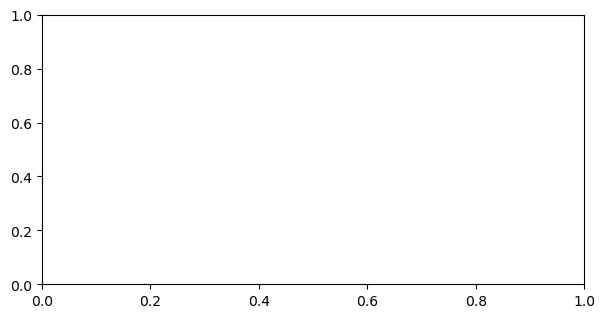

In [47]:
fig, ax = plt.subplots(figsize=(7, 3.5))

im = ax.imshow(
    data_numpy_upsample[0, :, :],
    cmap="gray",
    aspect="auto",
    origin="upper",
       # x index, z sample
)

ax.set_title(f"Angle stack °")
ax.set_xlabel("Lateral position x (index)")
ax.set_ylabel("Depth / time sample z")

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Amplitude")

plt.tight_layout()
plt.show()

### Reshape the well to go from 112 to 128

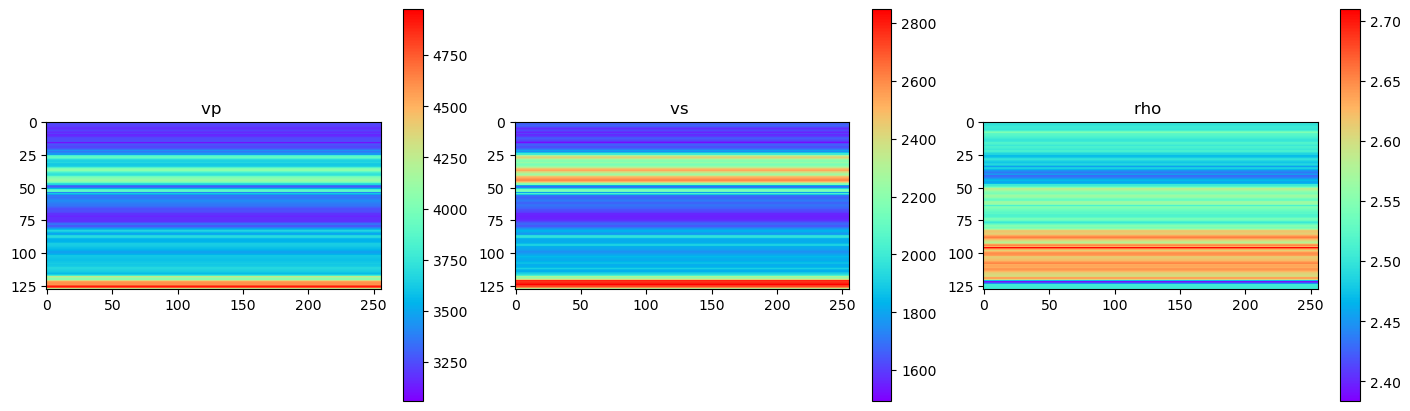

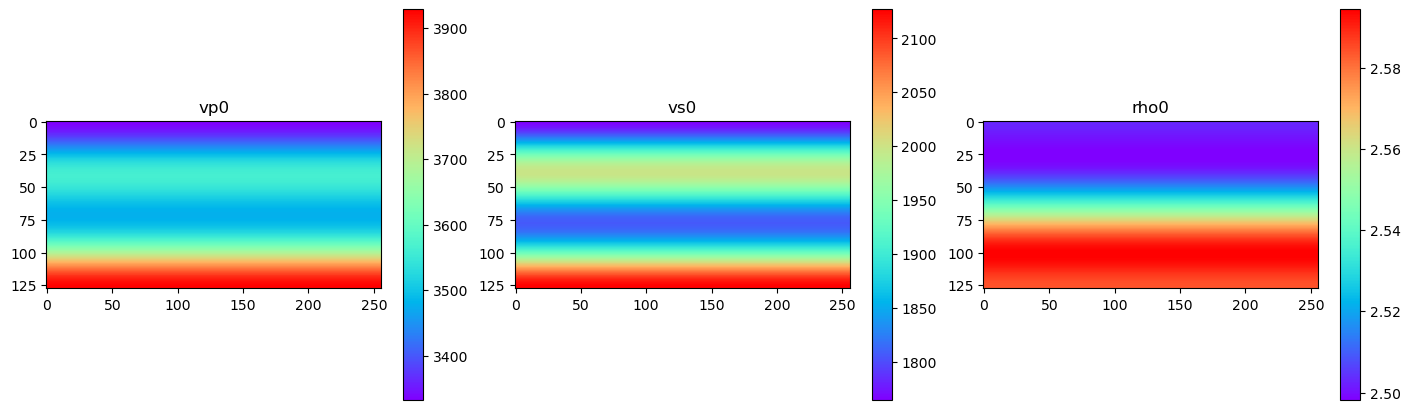

In [6]:
import torch
import torch.nn.functional as F

# Each well: (112,)
vp_well  = torch.tensor(well_vp,  dtype=torch.float32)
vs_well  = torch.tensor(well_vs,  dtype=torch.float32)
rho_well = torch.tensor(well_rho, dtype=torch.float32)

# Stack as channels → (C=3, L=112)
wells = torch.stack([vp_well, vs_well, rho_well], dim=0)

# Add batch dimension → (N=1, C=3, L=112)
wells = wells.unsqueeze(0)

# Interpolate all at once
wells_128 = F.interpolate(
    wells,
    size=128,
    mode="linear",
    align_corners=True
)

# Remove batch dim → (3, 128)
wells_128 = wells_128.squeeze(0)
vp_128, vs_128, rho_128 = wells_128

# convert back to numpy:
vp_128 = vp_128.numpy()
vs_128 = vs_128.numpy()
rho_128 = rho_128.numpy()

# Create 2D model by stacking the wells:
vp = np.tile(vp_128, (256,1)).T
vs = np.tile(vs_128, (256,1)).T
rho = np.tile(rho_128, (256,1)).T

# Show stacked wells
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp, cmap='rainbow');  axs[0].set_title("vp ");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs, cmap='rainbow');  axs[1].set_title("vs ");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho, cmap='rainbow'); axs[2].set_title("rho "); plt.colorbar(im, ax=axs[2])
plt.show()

# Smooth the stacked well to create a smooth initial model fo preconditioned structural inversion:
from scipy.ndimage import gaussian_filter
sigma_z = 20.0  # pixels
vp0 = gaussian_filter(vp, sigma=(sigma_z, sigma_z))
vs0 = gaussian_filter(vs, sigma=(sigma_z, sigma_z))
rho0 = gaussian_filter(rho, sigma=(sigma_z, sigma_z))

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp0, cmap='rainbow');  axs[0].set_title("vp0");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs0, cmap='rainbow');  axs[1].set_title("vs0");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho0, cmap='rainbow'); axs[2].set_title("rho0"); plt.colorbar(im, ax=axs[2])
plt.show()

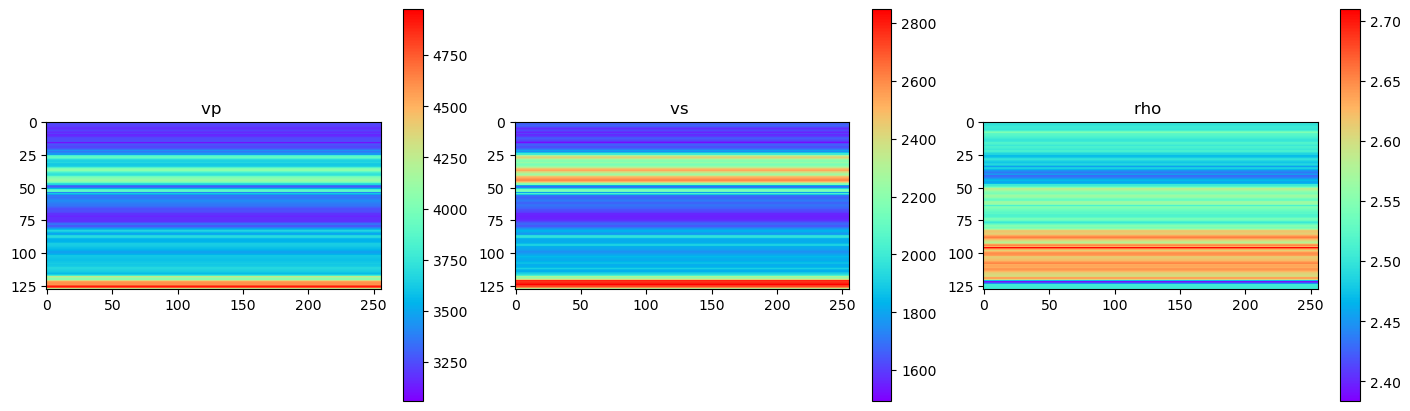

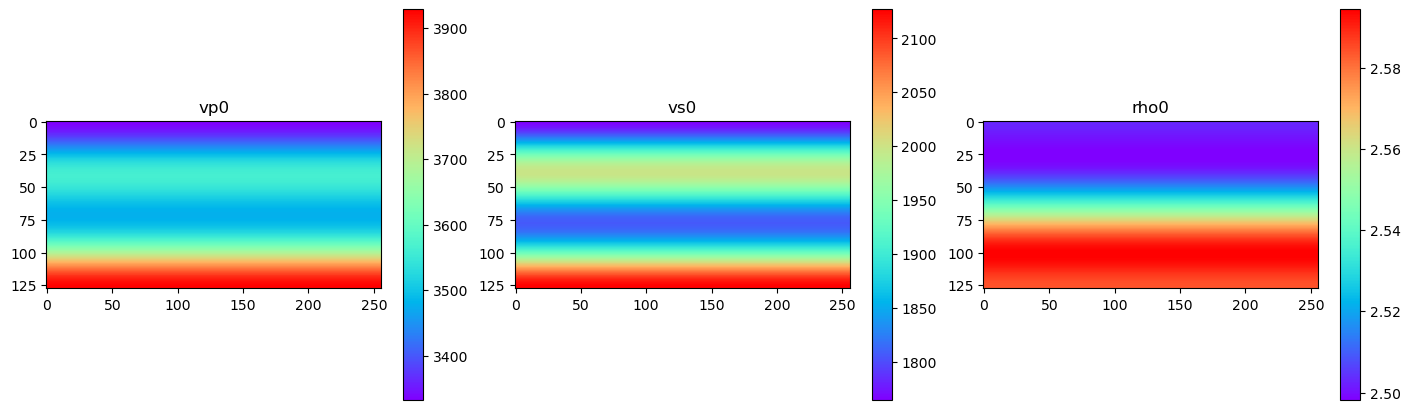

In [7]:
import torch
import torch.nn.functional as F

# Each well: (112,)
vp_well  = torch.tensor(well_vp,  dtype=torch.float32)
vs_well  = torch.tensor(well_vs,  dtype=torch.float32)
rho_well = torch.tensor(well_rho, dtype=torch.float32)

# Stack as channels → (C=3, L=112)
wells = torch.stack([vp_well, vs_well, rho_well], dim=0)

# Add batch dimension → (N=1, C=3, L=112)
wells = wells.unsqueeze(0)

# Interpolate all at once
wells_128 = F.interpolate(
    wells,
    size=128,
    mode="linear",
    align_corners=True
)

# Remove batch dim → (3, 128)
wells_128 = wells_128.squeeze(0)
vp_128, vs_128, rho_128 = wells_128

# convert back to numpy:
vp_128 = vp_128.numpy()
vs_128 = vs_128.numpy()
rho_128 = rho_128.numpy()

# Create 2D model by stacking the wells:
vp = np.tile(vp_128, (256,1)).T
vs = np.tile(vs_128, (256,1)).T
rho = np.tile(rho_128, (256,1)).T

# Show stacked wells
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp, cmap='rainbow');  axs[0].set_title("vp ");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs, cmap='rainbow');  axs[1].set_title("vs ");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho, cmap='rainbow'); axs[2].set_title("rho "); plt.colorbar(im, ax=axs[2])
plt.show()

# Smooth the stacked well to create a smooth initial model fo preconditioned structural inversion:
from scipy.ndimage import gaussian_filter
sigma_z = 20.0  # pixels
vp0 = gaussian_filter(vp, sigma=(sigma_z, sigma_z))
vs0 = gaussian_filter(vs, sigma=(sigma_z, sigma_z))
rho0 = gaussian_filter(rho, sigma=(sigma_z, sigma_z))

fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp0, cmap='rainbow');  axs[0].set_title("vp0");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs0, cmap='rainbow');  axs[1].set_title("vs0");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho0, cmap='rainbow'); axs[2].set_title("rho0"); plt.colorbar(im, ax=axs[2])
plt.show()

### Compute the local slope from angle stack

OMP: Info #277: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


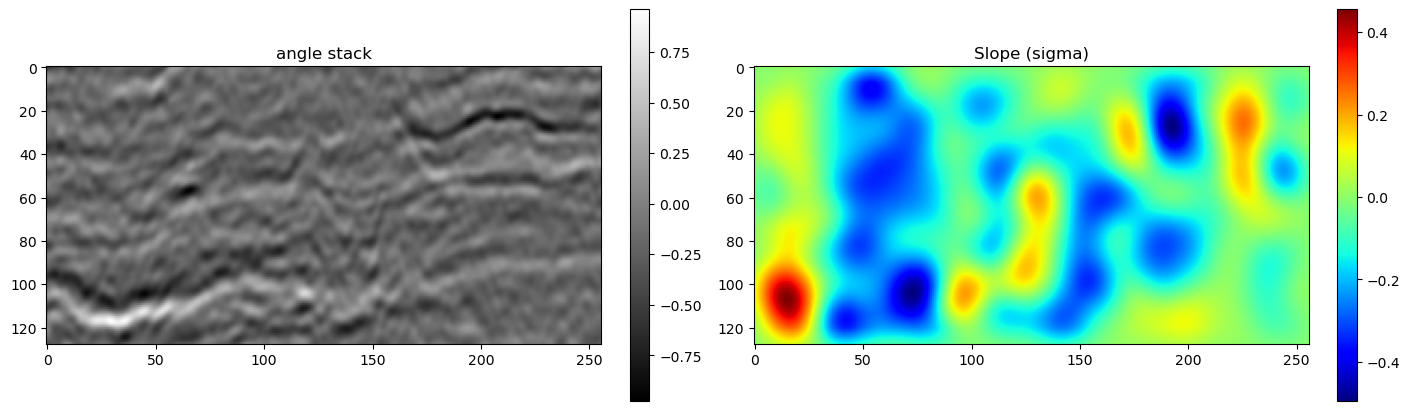

In [8]:
# Calculate pwd slope from true velocity (should be rtm or whatever image)
angle_idx = 0
sigma = pwddip2d(data_numpy_upsample[angle_idx,:,:], niter=5, liter=10, order=2, nsmooth=(30,30), damp=.1)

fig, axs = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(data_numpy_upsample[angle_idx,:,:], cmap='gray');  axs[0].set_title("angle stack");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(sigma, cmap='jet');  axs[1].set_title("Slope (sigma)");  plt.colorbar(im, ax=axs[1])
plt.show()

### Build operators for Structurally Preconditioned inversion:

In [9]:
# Build well sampling operator
well_loc = [241]
nz, nx = vp.shape[0], vp.shape[1]
MOp = pylops.Restriction(dims=(nz, nx), iava=well_loc,  axis=1)

# Build structural preconditioner
SOp = PWSmoother2D(dims=(nz, nx), sigma=sigma, radius=100, alpha=0.99, dtype="float32")

wells128 = [vp_128, vs_128, rho_128]
m0 = [vp0, vs0, rho0]

m_struct = []
for i in range(3):
    x_inv = pylops.optimization.leastsquares.preconditioned_inversion(MOp, 
                                                                wells128[i], 
                                                                SOp, 
                                                                x0=m0[i].ravel(), 
                                                                damp=np.sqrt(1e-2), 
                                                                iter_lim=100,
                                                                show=1
                                                                )[0]
    x_inv = x_inv.reshape(nz,nx)
    m_struct.append(x_inv)
    print(len(m_struct))


vp_struct = m_struct[0]
vs_struct = m_struct[1]
rho_struct = m_struct[2]

PreconditionedInversion
-----------------------------------------------------------------
The Operator Op has 128 rows and 32768 cols
Prec=<32768x32768 PWSmoother2D with dtype=float32>
-----------------------------------------------------------------
 
LSQR            Least-squares solution of  Ax = b
The matrix A has 128 rows and 32768 columns
damp = 1.00000000000000e-01   calc_var =        0
atol = 1.00e-06                 conlim = 1.00e+08
btol = 1.00e-06               iter_lim =      100
 
   Itn      x[0]       r1norm     r2norm   Compatible    LS      Norm A   Cond A
     0  0.00000e+00   3.062e+03  3.062e+03    1.0e+00  1.9e-01
     1  0.00000e+00   7.856e+02  7.856e+02    2.6e-01  7.7e-01   6.0e+02  1.0e+00
     2  0.00000e+00   4.938e+02  4.938e+02    1.6e-01  3.9e-01   8.5e+02  2.0e+00
     3  0.00000e+00   3.492e+02  3.492e+02    1.1e-01  2.7e-01   1.0e+03  3.4e+00
     4  0.00000e+00   2.745e+02  2.745e+02    9.0e-02  2.0e-01   1.1e+03  4.9e+00
     5  0.00000e+00   2.166e+

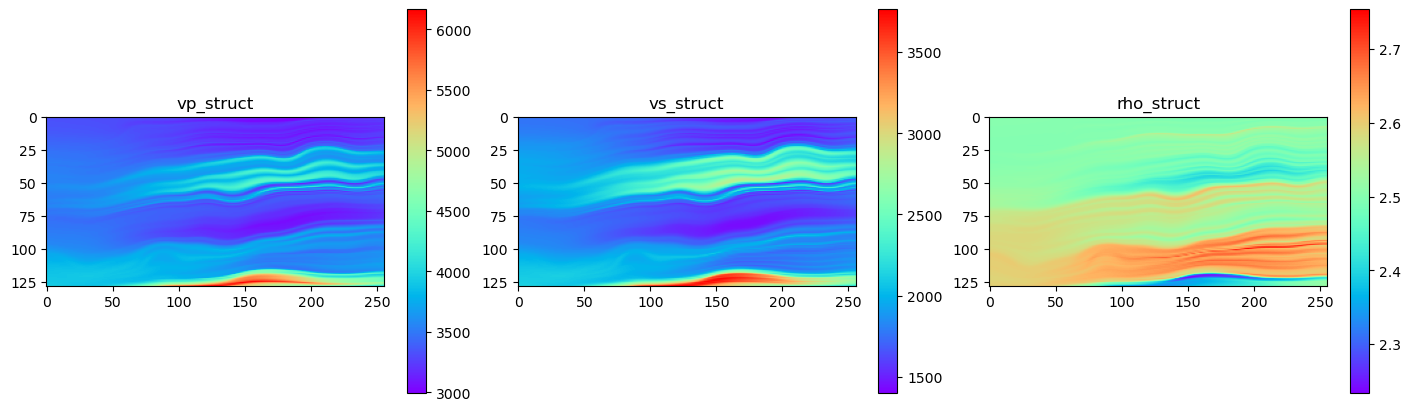

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
im = axs[0].imshow(vp_struct, cmap='rainbow');  axs[0].set_title("vp_struct");  plt.colorbar(im, ax=axs[0])
im = axs[1].imshow(vs_struct, cmap='rainbow');  axs[1].set_title("vs_struct");  plt.colorbar(im, ax=axs[1])
im = axs[2].imshow(rho_struct, cmap='rainbow'); axs[2].set_title("rho_struct"); plt.colorbar(im, ax=axs[2])
plt.show()

### Prepare inital model in log-domain for LinearPrestack Op.

In [15]:
# m0 in log domain
m0_log = np.stack( (np.log(vp_struct), np.log(vs_struct), np.log(rho_struct) ), axis=1 )
m0_log_smooth = np.stack( (np.log(vp0), np.log(vs0), np.log(rho0) ), axis=1 )

print('m0_log: ',m0_log.shape)

# Select near / far angle stack:
d_angle_stack = data_numpy_upsample[0,:,:].astype(np.float64)
d_angle_stack = d_angle_stack[:, None, :]   # (nz, 1, nx)
print('d_angle_stack: ',d_angle_stack.shape)

# Wavelet
wav_near = np.load('/home/brandof/Documents/dpsAVOinversion-dev/data/field_data/statistical_wavelet_near.npy')
wav_mid = np.load('/home/brandof/Documents/dpsAVOinversion-dev/data/field_data/statistical_wavelet_mid.npy')
wav_far = np.load('/home/brandof/Documents/dpsAVOinversion-dev/data/field_data/statistical_wavelet_far.npy')

wav = wav_near.astype(np.float64)

# select angles:
angles = np.array([6.0], dtype=np.float64)
print('theta: ', angles.shape)


m0_log:  (128, 3, 256)
d_angle_stack:  (128, 1, 256)
theta:  (1,)


In [22]:
import numpy as np
import pylops
from pylops.optimization.basic import lsqr

# -------------------------
# Inputs
# -------------------------
# d_near, d_mid, d_far: (nz, nx)  angle stacks
# wav_near, wav_mid, wav_far: (ntwav,) wavelets
# mback: (nz, 3, nx) background model in log-space (or zeros)
# nz, nx: ints
d_near, d_mid, d_far = data_numpy_upsample[0,:,:].astype(np.float64), data_numpy_upsample[1,:,:].astype(np.float64), data_numpy_upsample[1,:,:].astype(np.float64)
mback = m0_log_smooth
assert d_near.shape == (nz, nx)
assert d_mid.shape  == (nz, nx)
assert d_far.shape  == (nz, nx)
assert mback.shape  == (nz, 3, nx)

# -------------------------
# Define angle ranges (deg) and effective angles
# -------------------------
near_min, near_max = 0.0, 10.0
mid_min,  mid_max  = 10.0, 25.0
far_min,  far_max  = 25.0, 40.0

theta_near = 0.5 * (near_min + near_max)
theta_mid  = 0.5 * (mid_min  + mid_max)
theta_far  = 0.5 * (far_min  + far_max)

# -------------------------
# Build 3 operators (each outputs data of shape (nz, 1, nx) when reshaped)
# -------------------------
G_near = pylops.avo.prestack.PrestackLinearModelling(
    wav_near, np.array([theta_near]),
    nt0=nz, spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)

G_mid = pylops.avo.prestack.PrestackLinearModelling(
    wav_mid, np.array([theta_mid]),
    nt0=nz, spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)

G_far = pylops.avo.prestack.PrestackLinearModelling(
    wav_far, np.array([theta_far]),
    nt0=nz, spatdims=(nx,),
    linearization="akirich",
    explicit=False,
)

# Stack: data vector will be [d_near; d_mid; d_far]
G = pylops.VStack([G_near, G_mid, G_far])

print("G shape:", G.shape, "(data_size, model_size)")
print("Expected model size:", nz*3*nx)

# -------------------------
# Stack observed data consistently with VStack ordering
# -------------------------
# Each stack is (nz, nx). Make vectors in C-order.
dvec = np.concatenate([
    d_near.ravel(order="C"),
    d_mid.ravel(order="C"),
    d_far.ravel(order="C"),
], axis=0)

assert dvec.size == 3 * nz * nx

# -------------------------
# Invert
# -------------------------
# Use background as initial guess
x0 = mback.ravel(order="C")

# Damping: start not-too-small (AVO is ill-conditioned)
damp = 0.9
iter_lim = 200

sol = lsqr(G, dvec, x0=x0, damp=damp, niter=iter_lim)
minv_vec = sol[0]

minv = minv_vec.reshape(nz, 3, nx, order="C")

print("minv shape:", minv.shape)
print("LSQR iters:", sol[2], "||r||:", sol[3], "||A^T r||:", sol[4])


mlsqr_phy_vp = np.exp(minv[:, 0, :])  # Vp
mlsqr_phy_vs = np.exp(minv[:, 1, :])  # Vs
mlsqr_phy_rho = np.exp(minv[:, 2, :])  # Rho
mlsqr_phy = np.stack([mlsqr_phy_vp, mlsqr_phy_vs, mlsqr_phy_rho ], axis=0)

# -------------------------
# Data-fit check
# -------------------------
# dvec_pred = G * minv_vec
# res = dvec - dvec_pred
# print("Residual std:", np.std(res))

# # If residuals per stack:
# res_near = res[0:nz*nx].reshape(nz, nx, order="C")
# res_mid  = res[nz*nx:2*nz*nx].reshape(nz, nx, order="C")
# res_far  = res[2*nz*nx:3*nz*nx].reshape(nz, nx, order="C")


G shape: (98304, 98304) (data_size, model_size)
Expected model size: 98304
minv shape: (128, 3, 256)
LSQR iters: 26 ||r||: 82.19755289622533 ||A^T r||: 85.1732733836859


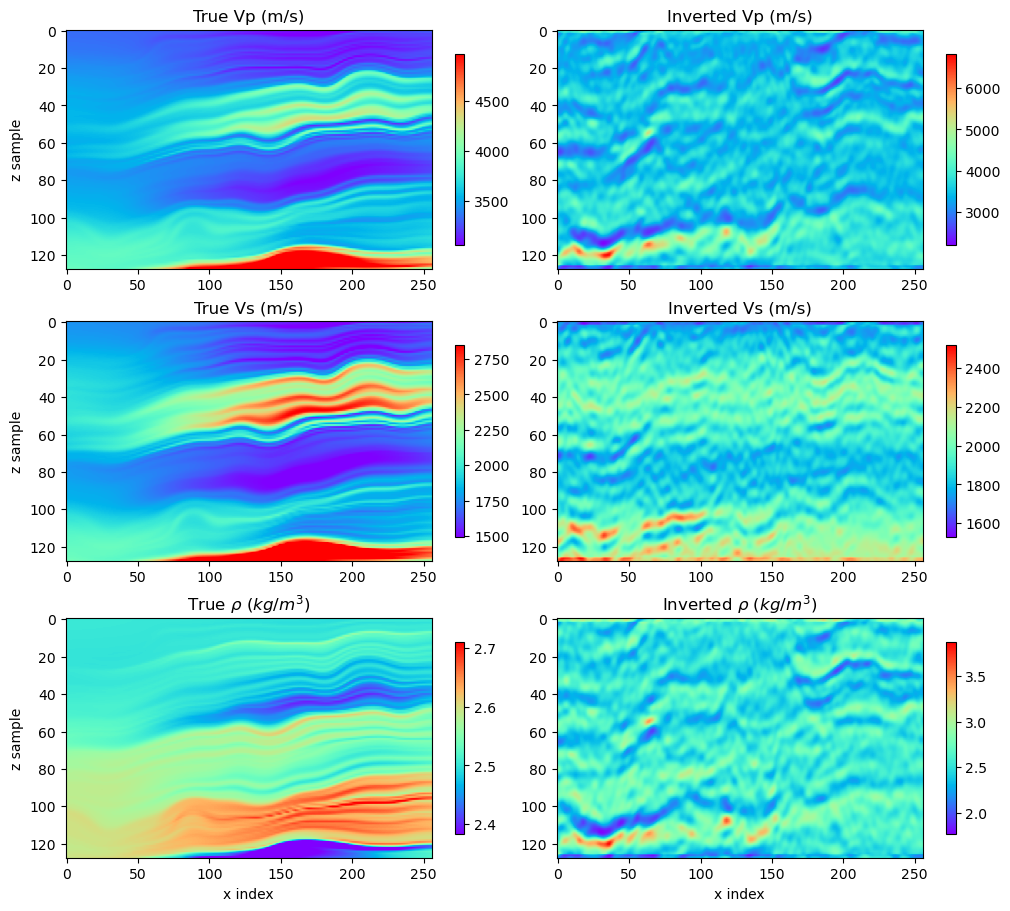

In [17]:
titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ $(kg/m^3)$"]
vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]
fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)

for i in range(3):
    im0 = axs[i, 0].imshow(np.exp(m0_log[:, i, :]), aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i])
    axs[i, 0].set_title(f"True {titles[i]}")
    axs[i, 0].set_ylabel("z sample")
    plt.colorbar(im0, ax=axs[i, 0], shrink=0.8)

    im1 = axs[i, 1].imshow(np.exp(minv[:, i, :]), aspect="auto", cmap="rainbow")
    axs[i, 1].set_title(f"Inverted {titles[i]}")
    plt.colorbar(im1, ax=axs[i, 1], shrink=0.8)

axs[-1, 0].set_xlabel("x index")
axs[-1, 1].set_xlabel("x index")
plt.show()


### Lets use a proper method ADMM + TV 

In [ ]:
import numpy as np
import pylops
from pyproximal import L21
from pyproximal.optimization.primal import ADMML2

# Model size
nmodel = nz * 3 * nx

# Derivatives on the full (nz, 3, nx) cube (only z and x axes!)
Dz = pylops.FirstDerivative(dims=(nz, 3, nx), axis=0, edge=True, dtype="float64")
Dx = pylops.FirstDerivative(dims=(nz, 3, nx), axis=2, edge=True, dtype="float64")

# A stacks the gradients: z = [Dz x; Dx x]
A = pylops.VStack([Dz, Dx])

# Prox for isotropic TV: || [Dz x; Dx x] ||_{2,1}
# ndim=2 because we stacked two gradient components (z and x)
lambda_tv = 2e-2   # start small; increase gradually (1e-2 -> 3e-2 -> 1e-1)
proxg = L21(ndim=2, sigma=lambda_tv)

# ADMM step size condition depends on A^H A; safe is tau <= 1 / lambda_max(A^H A)
# In practice start conservative:
tau = 0.3

# Run ADMM
x_admm, z_admm = ADMML2(
    proxg,
    Op=G,
    b=dvec,
    A=A,
    x0=x0,         # x0 should be log-space background vector
    tau=tau,
    niter=10,
    show=True,
    # kwargs for SciPy lsqr used internally in x-update
    iter_lim=200,
    damp=1,
    atol=1e-6,
    btol=1e-6,
)

mhat = x_admm.reshape(nz, 3, nx, order="C")

madmmtv_phy_vp = np.exp(mhat[:, 0, :])  # Vp
madmmtv_phy_vs = np.exp(mhat[:, 1, :])  # Vs
madmmtv_phy_rho = np.exp(mhat[:, 2, :])  # Rho
madmmtv_phy = np.stack([madmmtv_phy_vp, madmmtv_phy_vs, madmmtv_phy_rho ], axis=0)


ADMM
---------------------------------------------------------
Proximal operator (g): <class 'pyproximal.proximal.L21.L21'>
tau = 3.000000e-01	niter = 10

   Itn       x[0]          f           g       J = f + g
     1   8.23068e+00   3.520e+03   3.612e+01   3.556e+03
     2   8.30274e+00   3.333e+03   4.666e+01   3.379e+03
     3   8.36091e+00   3.256e+03   5.456e+01   3.310e+03
     4   8.40781e+00   3.214e+03   5.966e+01   3.274e+03
     5   8.44769e+00   3.186e+03   6.347e+01   3.250e+03
     6   8.48295e+00   3.165e+03   6.661e+01   3.232e+03
     7   8.51482e+00   3.147e+03   6.933e+01   3.217e+03
     8   8.54433e+00   3.133e+03   7.178e+01   3.205e+03
     9   8.57205e+00   3.120e+03   7.400e+01   3.194e+03
    10   8.59829e+00   3.109e+03   7.603e+01   3.185e+03

Total time (s) = 4.52
---------------------------------------------------------



In [23]:
madmmtv_phy_vp = np.exp(mhat[:, 0, :])  # Vp
madmmtv_phy_vs = np.exp(mhat[:, 1, :])  # Vs
madmmtv_phy_rho = np.exp(mhat[:, 2, :])  # Rho
madmmtv_phy = np.stack([madmmtv_phy_vp, madmmtv_phy_vs, madmmtv_phy_rho ], axis=0)

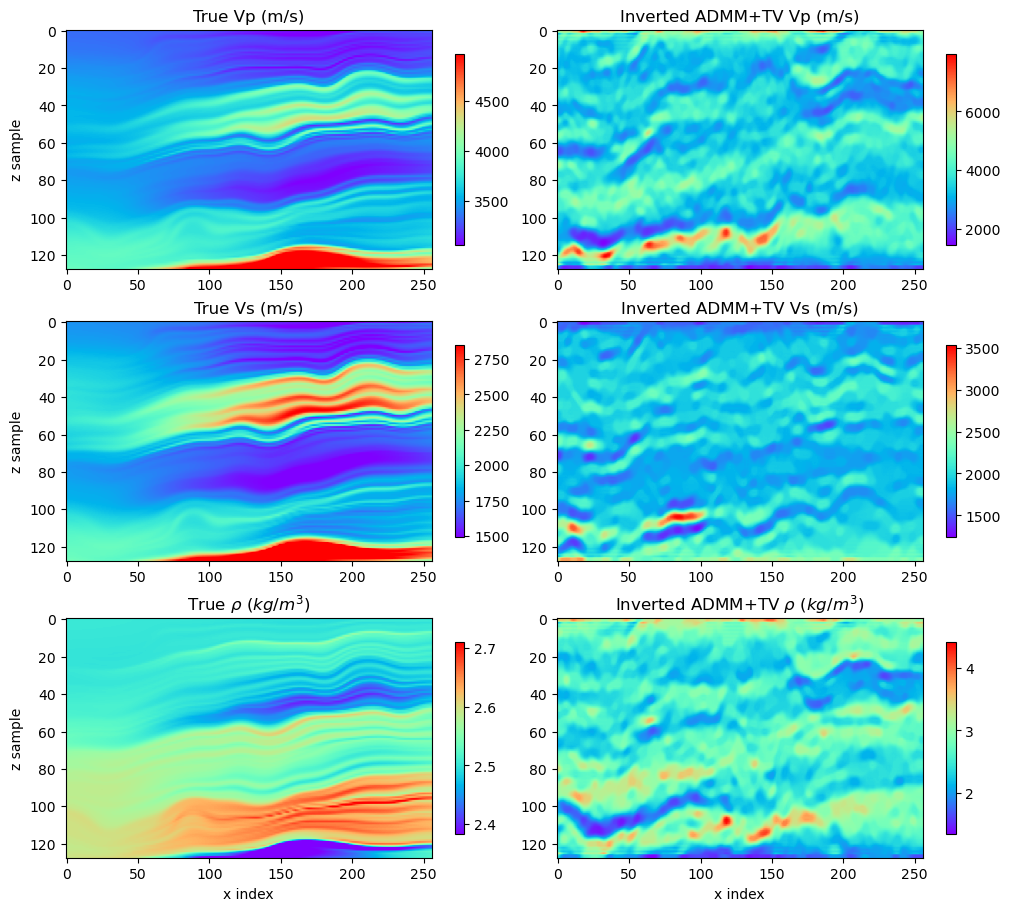

In [19]:
titles = ["Vp (m/s)", "Vs (m/s)", r"$\rho$ $(kg/m^3)$"]
vmin_true = [vp.min(), vs.min(), rho.min()]
vmax_true = [vp.max(), vs.max(), rho.max()]
fig, axs = plt.subplots(3, 2, figsize=(10, 9), constrained_layout=True)

for i in range(3):
    im0 = axs[i, 0].imshow(np.exp(m0_log[:, i, :]), aspect="auto", cmap="rainbow", vmin=vmin_true[i], vmax=vmax_true[i])
    axs[i, 0].set_title(f"True {titles[i]}")
    axs[i, 0].set_ylabel("z sample")
    plt.colorbar(im0, ax=axs[i, 0], shrink=0.8)

    im1 = axs[i, 1].imshow(np.exp(mhat[:, i, :]), aspect="auto", cmap="rainbow")
    axs[i, 1].set_title(f"Inverted ADMM+TV {titles[i]}")
    plt.colorbar(im1, ax=axs[i, 1], shrink=0.8)

axs[-1, 0].set_xlabel("x index")
axs[-1, 1].set_xlabel("x index")
plt.show()


In [42]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vp_vs_rho_single_well(
    m_lsqr, m_dps,
    vp_well, vs_well, rho_well,
    well_x,
    z=None,
    units=("m/s", "m/s", r" $kg/m^3$"),
    lw_true=1.5,
    lw_pred=1.8,
):
    """
    m_lsqr, m_dps : (3, nz, nx)
    vp_well, vs_well, rho_well : (nz,)
    well_x : int
    """

    _, nz, nx = m_lsqr.shape

    if z is None:
        z = np.arange(nz)

    # Extract predicted profiles at the well location
    vp_lsqr  = m_lsqr[0, :, well_x]
    vs_lsqr  = m_lsqr[1, :, well_x]
    rho_lsqr = m_lsqr[2, :, well_x]

    vp_dps   = m_dps[0, :, well_x]
    vs_dps   = m_dps[1, :, well_x]
    rho_dps  = m_dps[2, :, well_x]

    fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

    logs = [
        (vp_well,  vp_lsqr,  vp_dps,  "Vp",  units[0]),
        (vs_well,  vs_lsqr,  vs_dps,  "Vs",  units[1]),
        (rho_well, rho_lsqr, rho_dps, "Rho", units[2]),
    ]

    for ax, (true, lsqr, dps, title, unit) in zip(axes, logs):
        ax.plot(true, z, label="Well", linewidth=lw_true, color='k', linestyle="--")
        ax.plot(lsqr, z, label="LSQR", linewidth=lw_pred)
        ax.plot(dps,  z, label="ADMM+TV",  linewidth=lw_pred)

        ax.set_title(f"{title} [{unit}]")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()

    axes[0].set_ylabel("Time")
    axes[1].legend(loc="best")

    fig.suptitle(f"Well comparison at x = {well_x}", y=1.02)
    fig.tight_layout()
    plt.show()


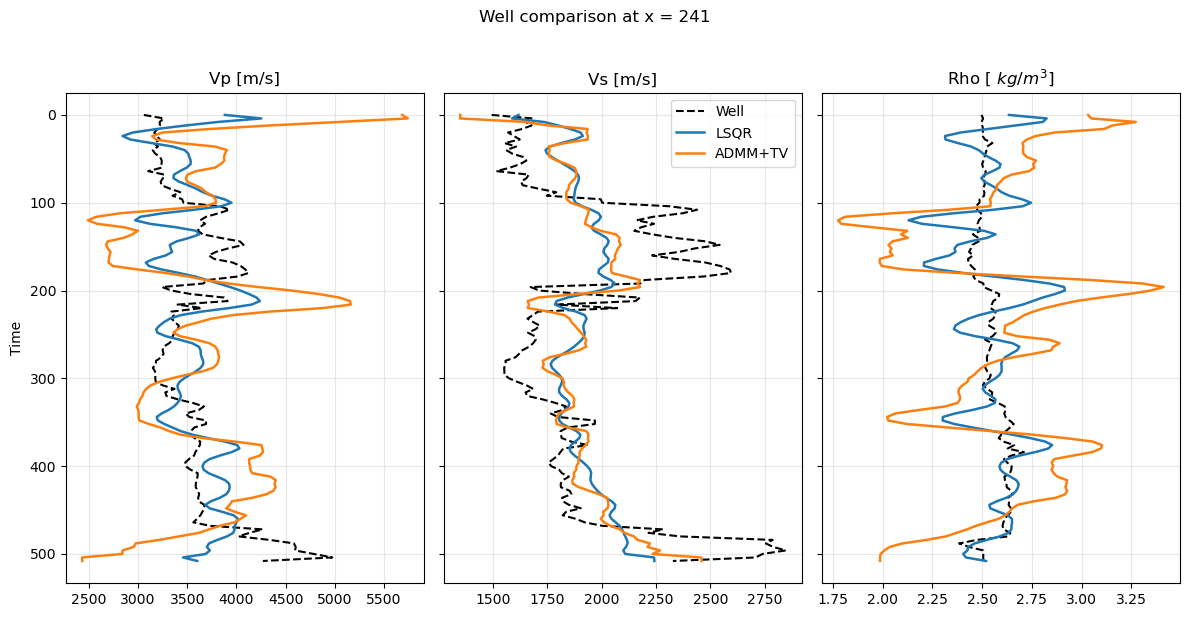

In [43]:


z = np.arange(128) * 4  # e.g. 5 m sampling

plot_vp_vs_rho_single_well(
    m_lsqr=mlsqr_phy,
    m_dps=madmmtv_phy,
    vp_well=wells128[0],
    vs_well=wells128[1],
    rho_well=wells128[2],
    well_x=well_loc,
    z=z
)